In [6]:
import json
import re
import pandas as pd

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

In [7]:
RESULTS_FILE = 'results/ictir_eval.jsonl'

with open(RESULTS_FILE) as f:
    rows = [json.loads(l) for l in f]

df = pd.DataFrame(rows)
print(f'{len(df)} rows, {df["model"].nunique()} models, {df["dataset"].nunique()} datasets')

235 rows, 9 models, 14 datasets


In [8]:
def parse_model(path):
    name = path.removeprefix('output/modernbert_').removesuffix('/final')
    stage = 'kd' if 'kd' in name.split('_') else 'contrastive'
    if 'colbert' in name:
        model_type = 'colbert'
    elif 'multi' in name:
        model_type = 'xtr_multi'
    else:
        m = re.search(r'k(\d+)', name)
        model_type = f'xtr_k{m.group(1)}'
    return model_type, stage

def short_dataset(d):
    if "beir" in d:
        dataset =  d.split('/')[-2] if (d.endswith('/test') or d.endswith('/v2')) else d.rsplit('/', 1)[-1]
        return f'B_{dataset}'
    elif "lotte" in d:
        #lotte/{split}/dev/search
        # return l_{split}
        dataset = d.split("/")[-3]
        return f'L_{dataset}'

df[['model_type', 'stage']] = df['model'].apply(lambda m: pd.Series(parse_model(m)))
df['dataset_short'] = df['dataset'].apply(short_dataset)
df['benchmark'] = df['dataset'].apply(lambda d: 'beir' if 'beir' in d else 'lotte')

MODEL_ORDER = ['colbert', 'xtr_k512', 'xtr_k256', 'xtr_k128', 'xtr_multi']
STAGE_ORDER = ['kd', 'contrastive']
INDEX_ORDER = ['warp', 'plaid']

df['model_type'] = pd.Categorical(df['model_type'], categories=MODEL_ORDER, ordered=True)
df['stage'] = pd.Categorical(df['stage'], categories=STAGE_ORDER, ordered=True)
df['index_type'] = pd.Categorical(df['index_type'], categories=INDEX_ORDER, ordered=True)

In [9]:
metrics = ['ndcg@10', 'recall@100', 'hit_rate@5', 'qps']
pt = df.query("model_type != 'xtr_k128'").pivot_table(
    index=['index_type', 'model_type', 'stage'],
    columns='dataset_short',
    values=metrics,
    sort=False,
).sort_index()

# Add avg columns in the order of metrics
for metric in metrics:
    pt[(metric, 'avg')] = pt[metric].mean(axis=1)

# Order the columns so metrics are in the given order for each dataset/avg
# This creates a MultiIndex with metrics as the first level ordered as in `metrics`
ordered_cols = []
# For each metric, gather all (metric, dataset) columns in order, plus the avg at the end
datasets = [c for c in pt.columns.get_level_values(1).unique() if c != 'avg']
for metric in metrics:
    for d in datasets:
        if (metric, d) in pt.columns:
            ordered_cols.append((metric, d))
    if (metric, 'avg') in pt.columns:
        ordered_cols.append((metric, 'avg'))

pt = pt[ordered_cols]

# Scale IR metrics to percentage points
for metric in ['ndcg@10', 'recall@100', 'hit_rate@5']:
    pt[metric] = pt[metric] * 100
pt.style.format('{:.1f}')


In [10]:
# Compute delta between 'kd' and 'contrastive' for each (index_type, model_type)
# The resulting pt_delta has the same columns as pt, but the index is (index_type, model_type)
pt_kd = pt.xs('kd', level='stage')
pt_contrastive = pt.xs('contrastive', level='stage')
pt_delta = pt_kd - pt_contrastive
pt_delta.index.names = ['index_type', 'model_type']

# Optionally format the output (as before)
pt_delta.style.format('{:.1f}')

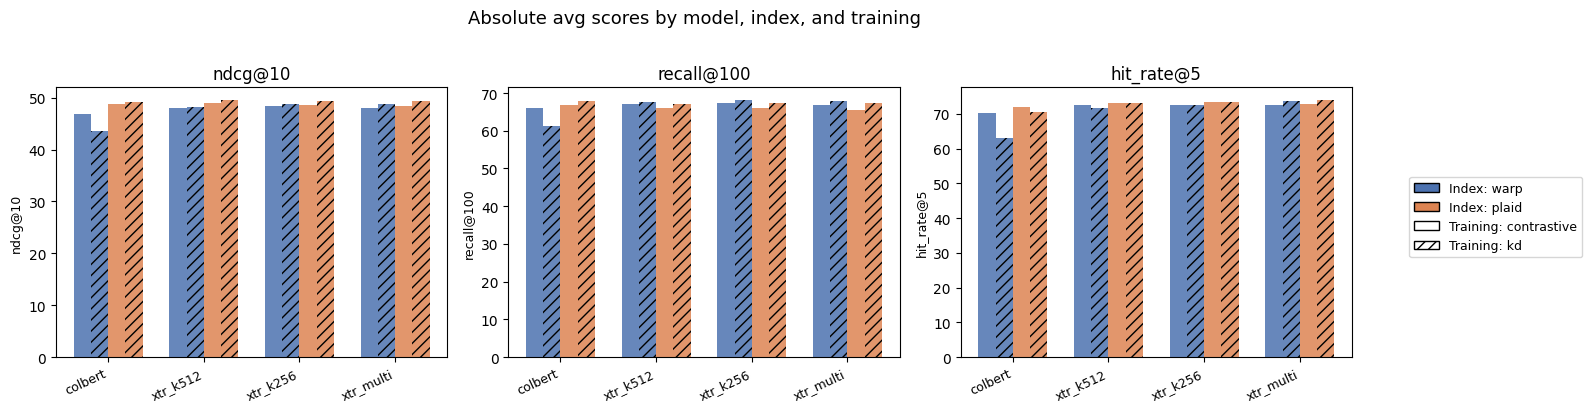

In [18]:
import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = ['ndcg@10', 'recall@100', 'hit_rate@5']
model_types = [m for m in MODEL_ORDER if m in pt.index.get_level_values('model_type').unique()]
index_types = [i for i in INDEX_ORDER if i in pt.index.get_level_values('index_type').unique()]
stages = ['contrastive', 'kd']

x = np.arange(len(model_types))
width = 0.18  # thinner bars since there will be 4 per group

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 4), sharey=False)

colors = {'warp': '#4C72B0', 'plaid': '#DD8452'}
hatches = {'contrastive': '', 'kd': '///'}

for ax, metric in zip(axes, metrics_to_plot):
    all_handles = []
    for i, idx_type in enumerate(index_types):
        for j, stage in enumerate(stages):
            # Compute left offset for each bar in a group (4 bars per group)
            pos_offset = (i * len(stages) + j - 1.5) * width
            vals = [
                pt.loc[(idx_type, m, stage), (metric, 'avg')]
                if (idx_type, m, stage) in pt.index else np.nan
                for m in model_types
            ]
            bars = ax.bar(
                x + pos_offset,
                vals,
                width,
                label=f"{stage} {idx_type}" if ax==axes[0] else "",
                color=colors.get(idx_type),
                alpha=0.85,
                hatch=hatches.get(stage, "")
            )
            if ax == axes[0]:
                all_handles.append(
                    (bars, stage, idx_type)
                )

    ax.set_title(metric, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(model_types, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel(f'{metric}', fontsize=9)

# Unified legend outside subplots
from matplotlib.patches import Patch

color_handles = [
    Patch(facecolor=colors[idx], edgecolor='k', label=idx) for idx in index_types
]
hatch_handles = [
    Patch(facecolor='white', edgecolor='k', label=stage, hatch=hatches[stage]) for stage in stages
]

# Create unified legend entries with description
legend_handles = (
    [Patch(facecolor=colors[idx], edgecolor='k', label=f"Index: {idx}") for idx in index_types] +
    [Patch(facecolor='white', edgecolor='k', hatch=hatches[stage], label=f"Training: {stage}") for stage in stages]
)

fig.suptitle('Absolute avg scores by model, index, and training', fontsize=13, y=1.02)

# Move the unified legend to the right of all subplots
fig.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9, borderaxespad=0.0)

plt.tight_layout(rect=[0, 0, 0.98, 1])  # leave space for legend
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics_to_plot = ['ndcg@10', 'recall@100', 'hit_rate@5']
model_types = [m for m in MODEL_ORDER if m in pt_delta.index.get_level_values('model_type').unique()]
index_types = [i for i in INDEX_ORDER if i in pt_delta.index.get_level_values('index_type').unique()]

x = np.arange(len(model_types))
width = 0.35

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 4), sharey=False)

colors = {'warp': '#4C72B0', 'plaid': '#DD8452'}

for ax, metric in zip(axes, metrics_to_plot):
    for i, idx_type in enumerate(index_types):
        vals = [
            pt_delta.loc[(idx_type, m), (metric, 'avg')]
            if (idx_type, m) in pt_delta.index else np.nan
            for m in model_types
        ]
        offset = (i - (len(index_types) - 1) / 2) * width
        ax.bar(x + offset, vals, width, label=idx_type, color=colors.get(idx_type), alpha=0.85)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(metric, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(model_types, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('KD − contrastive (pp)', fontsize=9)
    ax.legend(fontsize=9)

fig.suptitle('KD vs Contrastive: avg score change by model and index', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
